<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# A Neural Network to Classify n-Gons (Vielecke)

This notebook gives the first example of a neural network for a classification task. **Is there a triangle, quadrilateral, pentagon or hexagon in this image?**

<img src="ngon-ex.png" alt="noisy n-gon" width="150"/>
Solution: (expand the next cell)

  \
  There is a pentagon.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# load image data as numpy arrays (generated with a separate script available on request)
# Pickling is a way to store data structures on a drive - or cucumbers in a glass.
# load training data
with open("../data/ngons/ngon_train.pkl", "rb") as f:
    Xtrain, ytrain_class = pickle.load(f)
# load test data
with open("../data/ngons/ngon_test.pkl", "rb") as f:
    Xtest, ytest_class = pickle.load(f)

num_train = Xtrain.shape[0]
num_test = Xtest.shape[0]
height = Xtrain.shape[1]
width = Xtrain.shape[2]
img_size_flat = width * height

num_classes = 4 # 0, 1, 2, 3 for 3-, 4-, 5-, 6-gons

# one-hot encode output classes
ytrain = np.eye(num_classes, dtype=float)[ytrain_class]
ytest = np.eye(num_classes, dtype=float)[ytest_class]
print("Fraction of classes:", np.mean(ytrain, axis=0)) # close to 1/4 each

# normalize input to [0,1]
Xtrain = Xtrain / 255.
Xtest = Xtest / 255.

print("Size of training set is", num_train, ", size of test set is", num_test)

# Number of classes
num_classes = 4 # 0, 1, 2, 3 for 3, ..., 6 gons

Fraction of classes: [0.2567 0.2409 0.2502 0.2522]
Size of training set is 10000 , size of test set is 2000


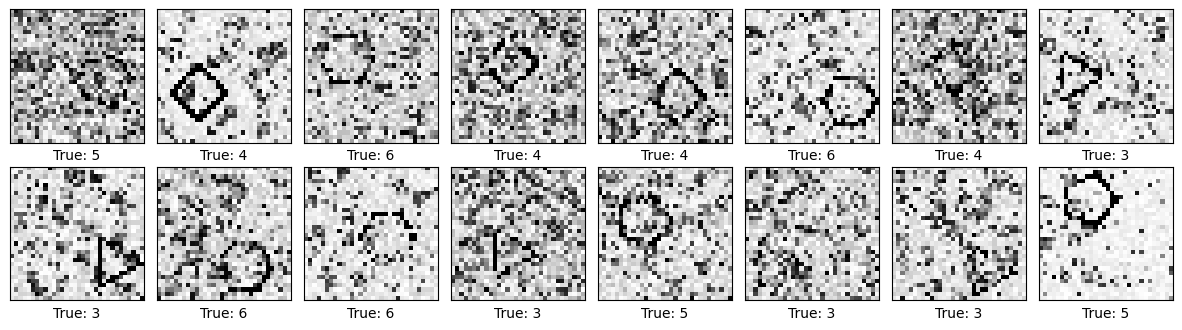

In [3]:
def plot_images(images, class_true, class_pred = None):
    """ Plot 16 (sample) images with their true and predicted classes"""
    assert len(images) == len(class_true) == 16

    # Create figure with sub-plots.
    fig, axes = plt.subplots(2, 8, figsize=(15, 4))
    fig.subplots_adjust(hspace=0.05, wspace=0.1)

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], interpolation = 'none', cmap = 'binary') # plot image

        # display also true and predicted classes
        if class_pred is None:
            xlabel = "True: {0}".format(3 + class_true[i])
        else:
            xlabel = "True: {0}, Pred: {1}".format(3 + class_true[i], 3 + class_pred[i])

        ax.set_xlabel(xlabel)

        # remove ticks from the plot
        ax.set_xticks([])
        ax.set_yticks([])


plot_images(Xtrain[0:16], ytrain_class[0:16])

## Create Datasets

In [4]:
print(Xtrain.shape, ytrain.shape)

(10000, 32, 32) (10000, 4)


In [5]:
# Convert training data to torch tensors.
Xtrain_tensor = torch.tensor(Xtrain, dtype=torch.float32)
# Use integer labels (not one-hot) for CrossEntropyLoss.
ytrain_tensor = torch.tensor(ytrain_class, dtype=torch.long)
dataset = TensorDataset(Xtrain_tensor, ytrain_tensor)

# Use 20% of training data as validation (matching validation_split = 0.2)
num_val = int(0.2 * num_train)
num_train_new = num_train - num_val
train_ds, val_ds = random_split(dataset, [num_train_new, num_val])

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

# Also create a test DataLoader
Xtest_tensor = torch.tensor(Xtest, dtype=torch.float32)
ytest_tensor = torch.tensor(ytest_class, dtype=torch.long)
test_ds = TensorDataset(Xtest_tensor, ytest_tensor)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

## Create Neural Network Model
We will use ```pytorch```, a high-level approach to neural network design and learning. 
As we will repeat the training with different regularization parameters (*weight decay*) we put this into a function.

In [6]:
# Define a multi-layer perceptron (MLP) model
#  Note: CrossEntropyLoss expects raw logits so we do not include softmax.
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(height * width, 3200),
    nn.ReLU(),
    nn.Linear(3200, 4)
)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=1024, out_features=3200, bias=True)
  (2): ReLU()
  (3): Linear(in_features=3200, out_features=4, bias=True)
)


In [7]:
# Set random seed for reproducibility
torch.manual_seed(10032025)

criterion = nn.CrossEntropyLoss()  # expects logits and integer labels
optimizer = optim.Adam(model.parameters(), lr=0.001)

# History dictionary similar to Keras' history.history
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

num_epochs = 25
model.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=1024, out_features=3200, bias=True)
  (2): ReLU()
  (3): Linear(in_features=3200, out_features=4, bias=True)
)

In [10]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += imgs.size(0)
    
    avg_train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += imgs.size(0)
    
    avg_val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history['loss'].append(avg_train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} -- Train loss: {avg_train_loss:.4f}, Train acc: {train_acc:.4f} ;  Val loss: {avg_val_loss:.4f}, Val acc: {val_acc:.4f}")

Epoch 1/25 -- Train loss: 1.3985, Train acc: 0.2589 ;  Val loss: 1.3996, Val acc: 0.2595
Epoch 2/25 -- Train loss: 1.3832, Train acc: 0.2840 ;  Val loss: 1.3964, Val acc: 0.2625
Epoch 3/25 -- Train loss: 1.3452, Train acc: 0.3481 ;  Val loss: 1.4060, Val acc: 0.2765
Epoch 4/25 -- Train loss: 1.3007, Train acc: 0.3920 ;  Val loss: 1.5017, Val acc: 0.2720
Epoch 5/25 -- Train loss: 1.2469, Train acc: 0.4376 ;  Val loss: 1.4470, Val acc: 0.2850
Epoch 6/25 -- Train loss: 1.2073, Train acc: 0.4661 ;  Val loss: 1.4508, Val acc: 0.2900
Epoch 7/25 -- Train loss: 1.1300, Train acc: 0.5110 ;  Val loss: 1.4521, Val acc: 0.2935
Epoch 8/25 -- Train loss: 1.0458, Train acc: 0.5601 ;  Val loss: 1.5075, Val acc: 0.3070
Epoch 9/25 -- Train loss: 0.9202, Train acc: 0.6329 ;  Val loss: 1.5224, Val acc: 0.3120
Epoch 10/25 -- Train loss: 0.7805, Train acc: 0.7107 ;  Val loss: 1.5247, Val acc: 0.3385
Epoch 11/25 -- Train loss: 0.6198, Train acc: 0.7934 ;  Val loss: 1.5421, Val acc: 0.3495
Epoch 12/25 -- Trai

In [11]:
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += imgs.size(0)
    
avg_test_loss = test_loss / test_total
test_acc = test_correct / test_total

print("Loss on test set:", avg_test_loss, "\nAccuracy on test set:", test_acc)

Loss on test set: 2.196993463516235 
Accuracy on test set: 0.412


### Plot the training history

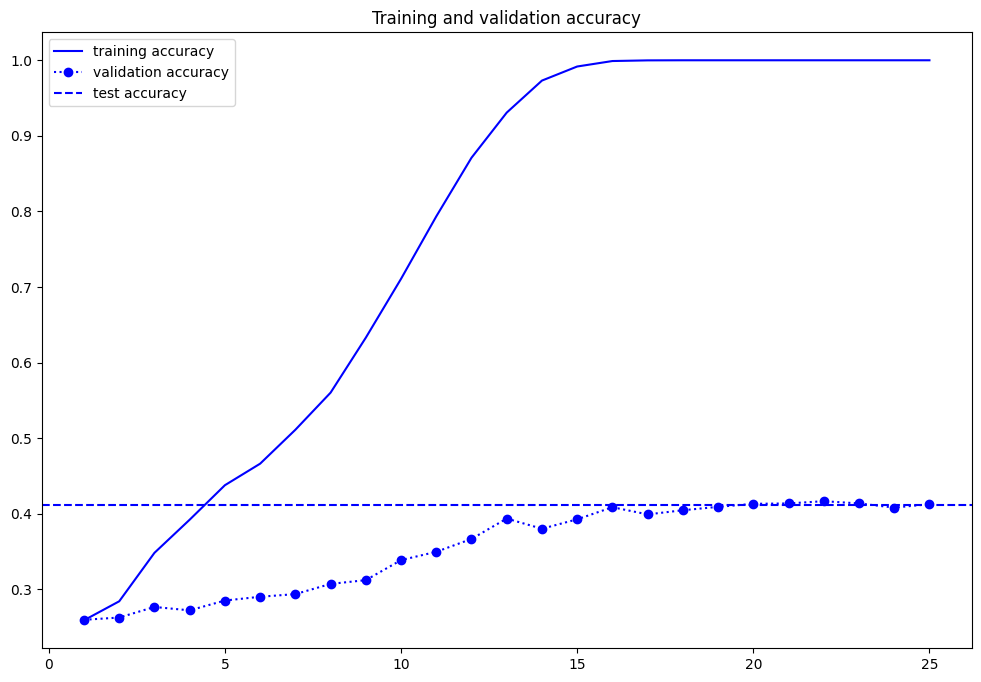

In [12]:
fig, ax = plt.subplots(figsize = (12, 8))

ax.set_title('Training and validation accuracy')

acc = history['accuracy']
val_acc = history['val_accuracy']
epochs = range(1, len(acc) + 1)

ax.plot(epochs, acc, color = "blue", label = "training accuracy")
ax.plot(epochs, val_acc, "o:", color = "blue", label = "validation accuracy")
ax.axhline(y = test_acc, color = "blue", linestyle = "--", label = "test accuracy")

ax.legend();

From above plot we see that the model classifies training data much better than test date (overfit). It indicates that a model with fewer parameters or regularization could be better.

# Make Predictions and Examine Errors

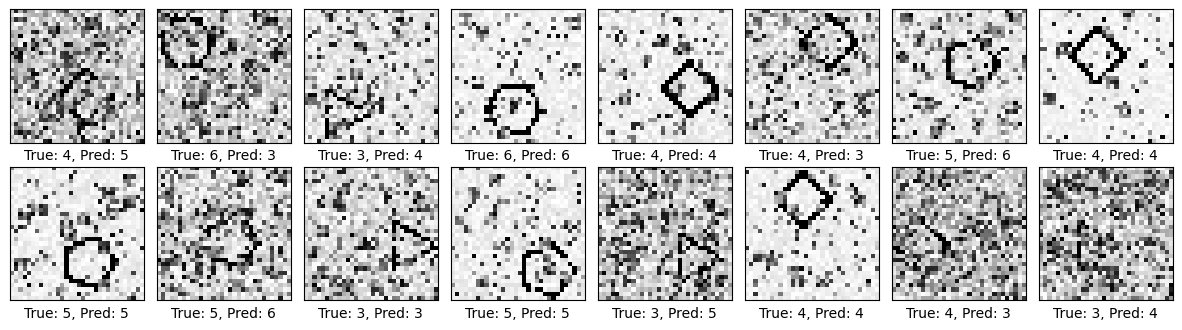

In [13]:
model.eval()
with torch.no_grad():
    # Get logits from model then compute probabilities via softmax
    outputs = model(torch.tensor(Xtest, dtype=torch.float32).to(device))
    probabilities = torch.softmax(outputs, dim=1)
    ytest_pred = probabilities.cpu().numpy()  # shape (num_test, 4)

ytest_predclass = np.argmax(ytest_pred, axis=1)
# Plot the first 16 test images with true and predicted classes
plot_images(Xtest[0:16], ytest_class[0:16], ytest_predclass[0:16])

### Not impressed? Wait until tomorrow ...